# Формула 1

На сайте kaggle есть dataset: https://www.kaggle.com/datasets/muhammadehsan02/formula-1-world-championship-history-1950-2024?resource=download&select=Track_Information.csv

Информация про гонщиков формулы 1. Мне необходимо предсказать кто из пилотов войдет в топ 10.

Целью является предсказать того, попадёт ли пилот в топ-10 по итогам гонки. Модель может использоваться для прогнозирования результатов гонок, анализа эффективности пилотов и команд, а также для поддержки принятия решений в спортивной аналитике.

Данная задача будет решаться в рамках **бинарной классификации**.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Импортируем необходимые библиотеки

In [3]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


Для удобной работы объединим **4** датасета в один

In [4]:
driver_details = pd.read_csv('/content/Driver_Details.csv')
driver_details.head(5)

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [5]:
qualifying = pd.read_csv('/content/Qualifying_Results.csv')
qualifying.head(5)

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [6]:
race = pd.read_csv('/content/Race_Results.csv')
race.head(5)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [7]:
team_details = pd.read_csv('/content/Team_Details.csv')
team_details.head(5)


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


Так как основной датасет это race result - начнем объединять с него

In [8]:
data_1 = race.merge(driver_details, how='left', on='driverId')
data_1.head(5)

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,fastestLapSpeed,statusId,driverRef,number_y,code,forename,surname,dob,nationality,url
0,1,18,1,1,22,1,1,1,1,10.0,...,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,18,2,2,3,5,2,2,2,8.0,...,217.586,1,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,18,3,3,7,7,3,3,3,6.0,...,216.719,1,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,18,4,4,5,11,4,4,4,5.0,...,215.464,1,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,18,5,1,23,3,5,5,5,4.0,...,218.385,1,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [9]:
data_2 = data_1.merge(team_details, how='left', on='constructorId')
data_2.head(5)

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,code,forename,surname,dob,nationality_x,url_x,constructorRef,name,nationality_y,url_y
0,1,18,1,1,22,1,1,1,1,10.0,...,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,18,2,2,3,5,2,2,2,8.0,...,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,18,3,3,7,7,3,3,3,6.0,...,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,18,4,4,5,11,4,4,4,5.0,...,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,18,5,1,23,3,5,5,5,4.0,...,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren


Используется объединённый датасет, включающий:

- результаты гонок (Race_Results)
- квалификацию (Qualifying_Results)
- данные о пилотах (Driver_details)
- данные о командах(Team_details)

In [10]:
data = data_2.merge(qualifying, how='left', on=['driverId', 'raceId'])
data.head(5)

,resultId,raceId,driverId,constructorId_x,number_x,grid,position_x,positionText,positionOrder,points,...,name,nationality_y,url_y,qualifyId,constructorId_y,number,position_y,q1,q2,q3
0,1,18,1,1,22,1,1,1,1,10.0,...,McLaren,British,http://en.wikipedia.org/wiki/McLaren,1.0,1.0,22.0,1.0,1:26.572,1:25.187,1:26.714
1,2,18,2,2,3,5,2,2,2,8.0,...,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,5.0,2.0,3.0,5.0,1:25.960,1:25.518,1:27.236
2,3,18,3,3,7,7,3,3,3,6.0,...,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,7.0,3.0,7.0,7.0,1:26.295,1:26.059,1:28.687
3,4,18,4,4,5,11,4,4,4,5.0,...,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,12.0,4.0,5.0,12.0,1:26.907,1:26.188,\N
4,5,18,5,1,23,3,5,5,5,4.0,...,McLaren,British,http://en.wikipedia.org/wiki/McLaren,3.0,1.0,23.0,3.0,1:25.664,1:25.452,1:27.079


In [11]:
data.to_csv('formula_one.csv', index=False)

# EDA

Переименуем столбцы, которым присвоен x или y

In [12]:
data = data.rename(columns={
    'position_x': 'race_position',
    'position_y': 'quali_position',
    'constructorId_x': 'constructorId_race',
    'constructorId_y': 'constructorId_quali'})

Для начала уберем столбцы связанные с национальнойстью и ссылкой на профиль гонщика, так как смысловой нагрузки в данном анализе не несет.

In [13]:
data.drop(columns=['nationality_x', 'nationality_y', 'url_x', 'url_y'], inplace=True)
data.head(5)

,resultId,raceId,driverId,constructorId_race,number_x,grid,race_position,positionText,positionOrder,points,...,dob,constructorRef,name,qualifyId,constructorId_quali,number,quali_position,q1,q2,q3
0,1,18,1,1,22,1,1,1,1,10.0,...,1985-01-07,mclaren,McLaren,1.0,1.0,22.0,1.0,1:26.572,1:25.187,1:26.714
1,2,18,2,2,3,5,2,2,2,8.0,...,1977-05-10,bmw_sauber,BMW Sauber,5.0,2.0,3.0,5.0,1:25.960,1:25.518,1:27.236
2,3,18,3,3,7,7,3,3,3,6.0,...,1985-06-27,williams,Williams,7.0,3.0,7.0,7.0,1:26.295,1:26.059,1:28.687
3,4,18,4,4,5,11,4,4,4,5.0,...,1981-07-29,renault,Renault,12.0,4.0,5.0,12.0,1:26.907,1:26.188,\N
4,5,18,5,1,23,3,5,5,5,4.0,...,1981-10-19,mclaren,McLaren,3.0,1.0,23.0,3.0,1:25.664,1:25.452,1:27.079


## Общая информация о данных

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26519 entries, 0 to 26518
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   resultId             26519 non-null  int64  
 1   raceId               26519 non-null  int64  
 2   driverId             26519 non-null  int64  
 3   constructorId_race   26519 non-null  int64  
 4   number_x             26519 non-null  object 
 5   grid                 26519 non-null  int64  
 6   race_position        26519 non-null  object 
 7   positionText         26519 non-null  object 
 8   positionOrder        26519 non-null  int64  
 9   points               26519 non-null  float64
 10  laps                 26519 non-null  int64  
 11  time                 26519 non-null  object 
 12  milliseconds         26519 non-null  object 
 13  fastestLap           26519 non-null  object 
 14  rank                 26519 non-null  object 
 15  fastestLapTime       26519 non-null 

необходимо:
- преобразовать типы данных
- обработки пропущенных значений
- кодирования категориальных признаков

In [15]:
data.describe()

,resultId,raceId,driverId,constructorId_race,grid,positionOrder,points,laps,statusId,qualifyId,constructorId_quali,number,quali_position
count,26519.000000,26519.000000,26519.000000,26519.000000,26519.000000,26519.000000,26519.000000,26519.000000,26519.000000,10254.000000,10254.000000,10254.000000,10254.000000
mean,13260.940986,546.376560,274.357291,49.801161,11.145820,12.814812,1.959578,46.228251,17.317056,5141.499415,46.884338,18.526624,11.212112
std,7656.813206,309.642244,279.275606,61.091426,7.213453,7.677869,4.306475,29.577860,26.081700,2976.371659,72.432640,18.243795,6.270548
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,6630.500000,298.000000,57.000000,6.000000,5.000000,6.000000,0.000000,23.000000,1.000000,2565.250000,4.000000,7.000000,6.000000
50%,13260.000000,527.000000,170.000000,25.000000,11.000000,12.000000,0.000000,53.000000,10.000000,5129.500000,9.000000,14.000000,11.000000
75%,19889.500000,803.000000,385.000000,60.000000,17.000000,18.000000,2.000000,66.000000,14.000000,7713.750000,30.000000,22.000000,16.000000
max,26524.000000,1132.000000,860.000000,215.000000,34.000000,39.000000,50.000000,200.000000,141.000000,10311.000000,215.000000,99.000000,28.000000


- Стартовая позиция (grid)  медиана около 11 (всего в сетке 20 пилотов)

- Итоговая позиция (race_position) имеет медиану 7, что близко к границе попадания в топ-10, а разброс значений отражает различие в результатах пилотов.

- Распределение очков (points) показывает, что большинство пилотов не набирают очки (медиана равна 0), однако максимальные значения достигают 50, что соответствует победе в гонке.

- Количество кругов (laps) в среднем составляет около 46, при этом наблюдается значительный разброс, связанный с различиями трасс и сезонов.

- Целевая переменная (top_ten) имеет среднее значение около 0.41 - умеренный баланс классов

### Размер датасете

In [16]:
data.shape

(26519, 33)

26519 - строки
34 - столбцы

## Анализ целевой переменной и выбор метрики

In [17]:
data['race_position'] = pd.to_numeric(data['race_position'], errors='coerce')
data['top_ten'] = (data['race_position'] <= 10).astype(int)
data['top_ten'].value_counts(normalize=True)

,proportion
top_ten,
0,0.590407
1,0.409593


В качестве основной метрики я выбрала F1-score.

Данные в целом сбалансировано(распределение целевой переменной показывает умеренный дисбаланс классов примерно 60% и 40%). F1 учитывает баланс между precision и recall и позволит более корректно оценивать качество классификации.

Я бы дополнительно использовала метрику ROC-AUC для оценки способности модели различать классы.

<Axes: xlabel='top_ten', ylabel='count'>

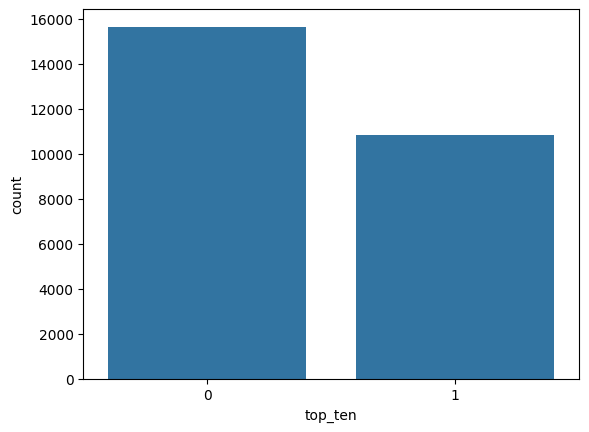

In [18]:
sns.countplot(x='top_ten', data=data)

Я проанализировала распределение целевой переменной топ 10 - классы распределены неравномерно: доля пилотов, не попадающих в топ-10, составляет около 60%, тогда как доля пилотов, попадающих в топ-10, — около 40%.

Такое распределение показывает умеренный дисбаланс классов.

## Анализ ключевых признаков

<Axes: xlabel='top_ten', ylabel='grid'>

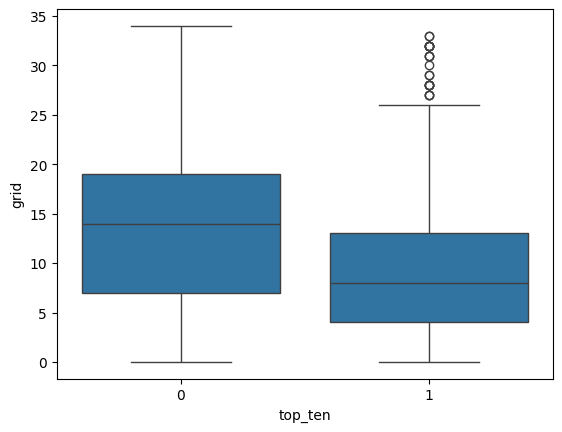

In [19]:
sns.boxplot(x='top_ten', y='grid', data=data)

Я заметила, что пилоты, стартующие с более высоких позиций, значительно чаще попадают в топ-10. Это объясняется тем, что в Formula 1 стартовая позиция оказывает существенное влияние на итоговый результат гонки.

Пилоты, находящиеся впереди, получают преимущество в виде «чистой» трассы, что позволяет им ехать в оптимальном темпе без потери времени за более медленными машинами. Кроме того, они реже попадают в инциденты на старте и в первых поворотах, где риск столкновений особенно высок.

Также важную роль играет стратегия: пилоты с хорошей стартовой позицией имеют больше возможностей контролировать гонку, выбирать оптимальные моменты для пит-стопов и избегать трафика -> напрямую влияет на итоговую позицию.

В то же время пилоты, стартующие с низких позиций, вынуждены активно обгонять, что связано с повышенным риском и потерей времени. Даже при высокой скорости машины это значительно снижает вероятность попадания в топ-10.

Когда пилоты с низких позиций достигают высоких результатов. Это может быть связано с нестандартными стратегиями, сходами соперников, погодными условиями или появлением машины безопасности, которые способны существенно изменить ход гонки.

<Axes: xlabel='grid', ylabel='Count'>

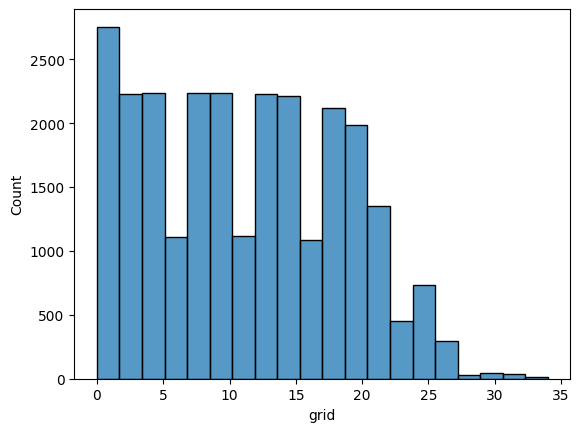

In [20]:
sns.histplot(data['grid'], bins=20)

Распределение признака grid является достаточно равномерным и не содержит выраженных аномалий.
Пилотов на старте 20 человек, поэтому распределение в равной степени соответствует от о до 20

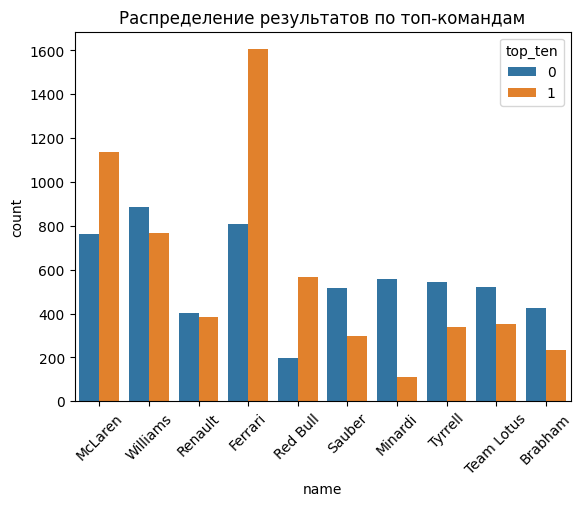

In [21]:
top_teams = data['name'].value_counts().head(10).index

sns.countplot(
    data=data[data['name'].isin(top_teams)],
    x='name',
    hue='top_ten'
)

plt.xticks(rotation=45)
plt.title('Распределение результатов по топ-командам')
plt.show()

У некоторых команд, таких как Ferrari и McLaren, количество попаданий в топ-10 значительно превышает количество случаев, когда пилоты не попадают в топ-10.

В Minardi или Sauber, наблюдается обратная ситуация: пилоты значительно чаще остаются вне топ-10.

Также можно увидеть, что даже среди топ-команд существует различие в результатах, что может быть связано с изменением их конкурентоспособности в разные сезоны.


***Ferrari болид***


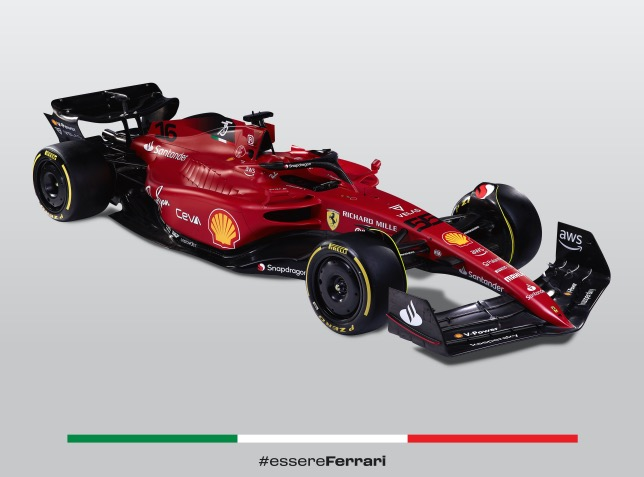

## Анализ пропусков

In [22]:
data.isna().sum().sort_values(ascending=False)

,0
q3,16292
q2,16278
qualifyId,16265
constructorId_quali,16265
q1,16265
quali_position,16265
number,16265
race_position,10928
raceId,0
resultId,0


q1, q2, q3 и др.- это этапы квалификации, которые определяют с какой позиции гонщики наичнают стартоват. Пропуски могут быть связаны с тем, что не все пилоты участвуют во всех этапах квалификации (например, выбывают на ранних стадиях), либо с отсутствием данных в отдельных сезонах.

Также присутствуют пропуски в признаке race_position, что может быть связано с тем, что некоторые пилоты не завершили гонку (сходы, технические проблемы и тд)

***Делаем выводы:***

Стартовая позиция влияет на то попадет пилот в топ 10 или нет.

Пилоты, стартующие с более высоких позиций, значительно чаще достигают высоких результатов, что подтверждается распределением признака grid.

Команды существенно различаются по количеству попаданий в топ-10, что указывает на важность технических характеристик болида.

В данных присутствуют пропуски, особенно в признаках, связанных с квалификацией и  требуют доп обработки.



# Построить и оценить качество бейзлайна

### Подготовка признаков и целевой переменной

В качестве целевой переменной используется признак `top_ten`, который показывает, попал ли пилот в топ-10 по итогам гонки.

Из набора признаков исключаются переменные, напрямую связанные с итоговым результатом гонки, поскольку они приводят к утечке целевой переменной.

In [23]:
data.columns = data.columns.str.strip()

In [24]:
target = 'top_ten'

columns_to_drop = [
    'top_ten',
    'race_position',
    'positionText',
    'positionOrder',
    'points',
    'time',
    'milliseconds',
    'fastestLap',
    'rank',
    'fastestLapTime',
    'fastestLapSpeed',
    'statusId',
    'resultId',
    'driverId',
    'raceId',
    'constructorId_race',
    'constructorId_quali',
    'qualifyId'
]

X = data.drop(columns=columns_to_drop, errors='ignore')
y = data[target]

X.head()

,number_x,grid,laps,driverRef,number_y,code,forename,surname,dob,constructorRef,name,number,quali_position,q1,q2,q3
0,22,1,58,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,mclaren,McLaren,22.0,1.0,1:26.572,1:25.187,1:26.714
1,3,5,58,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,bmw_sauber,BMW Sauber,3.0,5.0,1:25.960,1:25.518,1:27.236
2,7,7,58,rosberg,6,ROS,Nico,Rosberg,1985-06-27,williams,Williams,7.0,7.0,1:26.295,1:26.059,1:28.687
3,5,11,58,alonso,14,ALO,Fernando,Alonso,1981-07-29,renault,Renault,5.0,12.0,1:26.907,1:26.188,\N
4,23,3,58,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,mclaren,McLaren,23.0,3.0,1:25.664,1:25.452,1:27.079


### Разбиение данных на обучающую и тестовую выборки


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (21215, 16)
X_test: (5304, 16)
y_train: (21215,)
y_test: (5304,)


### Анализ пропущенных значений

Перед обучением моделей необходимо проверить наличие пропусков. Особенно важно это для признаков, связанных с квалификацией, так как в них ранее уже были обнаружены пропущенные значения.

In [26]:
X_train.isna().sum().sort_values(ascending=False).head(15)

,0
q3,13003
q2,12990
q1,12981
number,12981
quali_position,12981
number_x,0
laps,0
grid,0
surname,0
forename,0


Наибольшее количество пропусков в признаках, связанных с квалификацией.  
Для числовых признаков используется заполнение медианой, а для категориальных — наиболее частым значением.

### Константное предсказание

В качестве наивного бейзлайна используется `DummyClassifier` со стратегией `most_frequent`, который всегда предсказывает наиболее частотный класс.


In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)

y_pred_dummy = dummy_clf.predict(X_test)

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_f1 = f1_score(y_test, y_pred_dummy)

print('DummyClassifier')
print('Accuracy:', dummy_accuracy)
print('F1-score:', dummy_f1)

DummyClassifier
Accuracy: 0.5904977375565611
F1-score: 0.0


Константная модель задаёт минимальный уровень качества.  
Так как она всегда предсказывает только наиболее частотный класс, значение F1-score оказывается низким, что особенно важно для задачи классификации.

### Предобработка данных

Для baseline-модели используется раздельная обработка числовых и категориальных признаков:

- для числовых признаков применяется заполнение пропусков медианой;
- для категориальных — заполнение наиболее частым значением и последующее кодирование с помощью `OneHotEncoder`.


In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_features = ['grid', 'quali_position', 'number']
categorical_features = ['driverRef', 'constructorRef', 'name', 'number']

available_numeric = [col for col in numeric_features if col in X_train.columns]
available_categorical = [col for col in categorical_features if col in X_train.columns]

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median', add_indicator=True))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, available_numeric),
        ('cat', categorical_transformer, available_categorical)
    ]
)

### Обучение baseline-модели

В качестве обучаемой baseline-модели выбрано дерево решений (`DecisionTreeClassifier`).  

Использование Pipeline позволяет избежать утечки данных, так как предобработка выполняется отдельно для обучающей и тестовой выборок.

In [77]:
from sklearn.tree import DecisionTreeClassifier

baseline_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]
)

baseline_model.fit(X_train, y_train)

y_pred_tree = baseline_model.predict(X_test)
y_proba_tree = baseline_model.predict_proba(X_test)[:, 1]

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
tree_roc_auc = roc_auc_score(y_test, y_proba_tree)

print('DecisionTreeClassifier')
print(f'Accuracy: {tree_accuracy:.3f}')
print(f'F1-score: {tree_f1:.3f}')
print(f'ROC-AUC: {tree_roc_auc:.3f}')

DecisionTreeClassifier
Accuracy: 0.684
F1-score: 0.535
ROC-AUC: 0.760


In [78]:
results = pd.DataFrame({
    'Model': ['DummyClassifier', 'DecisionTreeClassifier'],
    'Accuracy': [dummy_accuracy, tree_accuracy],
    'F1-score': [dummy_f1, tree_f1],
    'ROC-AUC': [None, tree_roc_auc]
})

results.round(3)

,Model,Accuracy,F1-score,ROC-AUC
0,DummyClassifier,0.590,0.000,NaN
1,DecisionTreeClassifier,0.684,0.535,0.76


По сравнению с `DummyClassifier`, дерево решений показывает заметное улучшение качества.  
Это свидетельствует о том, что выбранные признаки содержат информативные зависимости, позволяющие предсказывать попадание пилота в топ-10.

## Вывод

По результатам сравнения моделей можно сделать несколько выводов.

Константная модель (`DummyClassifier`) показывает качество на уровне наиболее частотного класса (accuracy ≈ 0.59) и не способна корректно предсказывать положительный класс, что подтверждается значением F1-score, равным 0. Это говорит о том, что наивный подход не подходит для решения данной задачи.

Обучаемая модель (`DecisionTreeClassifier`) демонстрирует значительное улучшение качества: значение accuracy увеличивается до 0.68, а F1-score достигает 0.53, что свидетельствует о способности модели находить баланс между precision и recall. Кроме того, значение ROC-AUC ≈ 0.76 указывает на хорошую способность модели различать классы.

Полученные результаты подтверждают, что выбранные признаки (в частности, стартовая позиция и результаты квалификации) действительно содержат информативные зависимости, позволяющие предсказывать попадание пилота в топ-10.

Так обучаемая модель значительно превосходит наивный бейзлайн, что подтверждает корректность выбранного подхода и пригодность данных для решения задачи бинарной классификации.

# Построить более сложную модель с подбором гиперпараметров дз 14.04.2026

Я хочу рассмотреть для своей модели оба варианта и автоматический подбор гиперпараметров с помощью методам Optuna и с помощью ручного подбора

In [79]:
from sklearn.model_selection import GridSearchCV

In [80]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median'))]),
                                 ['grid', 'quali_position', 'number']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['driverRef', 'constructorRef', 'name',
                                  'number'])])


### GridSearch

In [81]:
param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
    'classifier__class_weight': [None, 'balanced']
}

In [82]:
grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=2
)

In [83]:
%%time

grid_search.fit(X_train, y_train)

CPU times: user 27 s, sys: 1.04 s, total: 28.1 s
Wall time: 5min 17s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(add_indicator=True,
                                                                                                        strategy='median'))]),
                                                                         ['grid',
                                                                          'quali_position',
                                                                          'number']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['driverRef',
                                                                          'constructorRef',
                                                                          'name',
                                                                          'number'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(max_depth=5,
                                                               random_state=42))]),
             n_jobs=2,
             param_grid={'classifier__class_weight': [None, 'balanced'],
                         'classifier__max_depth': [3, 5, 7, 10, None],
                         'classifier__min_samples_leaf': [1, 2, 4, 8],
                         'classifier__min_samples_split': [2, 5, 10, 20]},
             scoring='f1')

In [84]:
best_parametrs = grid_search.best_estimator_.get_params()
for param_name in sorted(param_grid.keys()):
  print(f"{param_name}: {best_parametrs[param_name]}")

classifier__class_weight: balanced
classifier__max_depth: 3
classifier__min_samples_leaf: 1
classifier__min_samples_split: 2


Лушчие результат глубины дерева это 3, значит более глубокие деревья ухудшали качество и при увеличении сложности начиналось переобучение

In [85]:
grid_search.best_estimator_.score(X_test, y_test)

0.6510180995475113

Улучшение качества незначительное, что указывает на ограниченную сложность зависимостей в данных и необходимость использования более мощных моделей

Попробуем использовать метод Optuna для повышения гиперпарамеров

In [87]:
%%capture

!pip install optuna

In [93]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [94]:
def objective(trial):
  model = Pipeline(
  steps=[
            ('preprocessor', preprocessor),
            ('classifier', DecisionTreeClassifier(
                random_state=42,
                max_depth=trial.suggest_categorical('max_depth', [3, 5, 7, 10, None]),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 8),
                class_weight=trial.suggest_categorical('class_weight', [None, 'balanced']),
                criterion=trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])
            ))
        ]
    )
  scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
  return scores.mean()


In [95]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print('Best trial score:', study.best_value)
print('Best params:', study.best_params)

[I 2026-04-14 10:54:40,129] A new study created in memory with name: no-name-85d87485-23a7-46fd-9095-c2b7953c97c0
[I 2026-04-14 10:54:44,931] Trial 0 finished with value: 0.6551460725477252 and parameters: {'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 7, 'class_weight': 'balanced', 'criterion': 'gini'}. Best is trial 0 with value: 0.6551460725477252.
[I 2026-04-14 10:54:46,463] Trial 1 finished with value: 0.6549535604068039 and parameters: {'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 8, 'class_weight': 'balanced', 'criterion': 'gini'}. Best is trial 0 with value: 0.6551460725477252.
[I 2026-04-14 10:54:48,604] Trial 2 finished with value: 0.5909098064722403 and parameters: {'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 1, 'class_weight': None, 'criterion': 'gini'}. Best is trial 0 with value: 0.6551460725477252.
[I 2026-04-14 10:54:50,083] Trial 3 finished with value: 0.6500153333552287 and parameters: {'max_depth': 7, 'min_samples_split'

Best trial score: 0.6606449938241707
Best params: {'max_depth': 3, 'min_samples_split': 18, 'min_samples_leaf': 1, 'class_weight': 'balanced', 'criterion': 'log_loss'}


In [97]:
study.best_trial

FrozenTrial(number=44, state=<TrialState.COMPLETE: 1>, values=[0.6606449938241707], datetime_start=datetime.datetime(2026, 4, 14, 10, 55, 49, 634395), datetime_complete=datetime.datetime(2026, 4, 14, 10, 55, 50, 284430), params={'max_depth': 3, 'min_samples_split': 18, 'min_samples_leaf': 1, 'class_weight': 'balanced', 'criterion': 'log_loss'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'max_depth': CategoricalDistribution(choices=(3, 5, 7, 10, None)), 'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=8, log=False, low=1, step=1), 'class_weight': CategoricalDistribution(choices=(None, 'balanced')), 'criterion': CategoricalDistribution(choices=('gini', 'entropy', 'log_loss'))}, trial_id=44, value=None)

### Рассмотрим более сложную ML модель

In [105]:
!pip install CatBoost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.8 MB/s eta 0:00:00


In [127]:
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [116]:
models = {
    'DecisionTree': DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=18,
        min_samples_leaf=1,
        class_weight='balanced',
        criterion='log_loss',
        random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

results = []

for model_name, classifier in models.items():
    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', classifier)
        ]
    )

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, 'predict_proba') else None

    row = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }

    results.append(row)

results_df = pd.DataFrame(results).sort_values(by='f1', ascending=False)
results_df

,model,accuracy,f1,roc_auc
0,DecisionTree,0.684012,0.667987,0.736934
2,GradientBoosting,0.701357,0.600000,0.777576
1,RandomForest,0.695136,0.585278,0.766426


Подготовка данных

In [157]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy='median')
categorical_imputer = SimpleImputer(strategy='most_frequent')

X_train_num = numeric_imputer.fit_transform(X_train[numeric_features])
X_test_num = numeric_imputer.transform(X_test[numeric_features])

X_train_cat = categorical_imputer.fit_transform(X_train[categorical_features]).astype(str)
X_test_cat = categorical_imputer.transform(X_test[categorical_features]).astype(str)

X_train_cb = np.hstack([X_train_num, X_train_cat])
X_test_cb = np.hstack([X_test_num, X_test_cat])

cat_features_idx = list(range(len(numeric_features), X_train_cb.shape[1]))

Для catboost отдельная подготовка данных без OneHotEncoder

In [118]:
cb_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)

cb_model.fit(X_train_cb, y_train, cat_features=cat_features_idx)

y_pred_cb = cb_model.predict(X_test_cb)
y_proba_cb = cb_model.predict_proba(X_test_cb)[:, 1]

catboost_row = {
    'model': 'CatBoost',
    'accuracy': accuracy_score(y_test, y_pred_cb),
    'f1': f1_score(y_test, y_pred_cb),
    'roc_auc': roc_auc_score(y_test, y_proba_cb)
}

results_df = pd.concat([results_df, pd.DataFrame([catboost_row])], ignore_index=True)
results_df = results_df.sort_values(by='f1', ascending=False)
results_df

,model,accuracy,f1,roc_auc
0,DecisionTree,0.684012,0.667987,0.736934
3,CatBoost,0.705505,0.618093,0.787037
1,GradientBoosting,0.701357,0.600000,0.777576
2,RandomForest,0.695136,0.585278,0.766426


In [158]:
thresholds = np.linspace(0, 1, 100)
f1_scores = []

for t in thresholds:
    y_pred_custom = (y_proba_cb >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_custom))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(best_threshold, best_f1)

0.32323232323232326 0.6886774855437419


In [159]:
y_pred_final = (y_proba_cb >= best_threshold).astype(int)

print(f'F1: {f1_score(y_test, y_pred_final):.3f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_final):.3f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_cb):.3f}')

F1: 0.689
Accuracy: 0.685
ROC-AUC: 0.786


Для выбора финальной модели было проведено сравнительное исследование нескольких алгоритмов: Decision Tree, Random Forest, Gradient Boosting и CatBoost. Все модели оценивались на одной и той же обучающей и отложенной выборке, а основным критерием выбора служила метрика F1-score. Такой подход позволил не ограничиваться одной моделью заранее, а эмпирически определить наиболее подходящий алгоритм для рассматриваемой задачи.

При сравнении моделей обнаруживается важное различие в их поведении. Модель *DecisionTree показывает наилучшее значение F1-score*, однако при этом демонстрирует более низкое значение ROC-AUC. В то же время модель CatBoost уступает по F1-score, но значительно превосходит DecisionTree по метрике ROC-AUC.

DecisionTree хорошо справляется с классификацией при фиксированном пороге (по умолчанию 0.5), что позволяет ему достигать высокого значения F1-score. Однако при этом модель хуже оценивает вероятности принадлежности объектов к классам, что проявляется в более низком значении ROC-AUC. Иными словами, она менее эффективно ранжирует объекты по степени уверенности.

CatBoost, напротив, лучше улавливает структуру данных и формирует более качественные вероятностные оценки, что отражается в высоком значении ROC-AUC. Однако использование стандартного порога классификации (0.5) не позволяет в полной мере реализовать её потенциал с точки зрения F1-score, поэтому данная метрика оказывается ниже.



### Подберем гиперпарамтеры методом Optuna

In [149]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 800),
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 5.0),
        'loss_function': 'Logloss',
        'eval_metric': 'F1',
        'random_state': 42,
        'verbose': 0
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train_cb, y_train):
        X_tr = X_train_cb[train_idx]
        X_val = X_train_cb[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, cat_features=cat_features)

        preds = model.predict(X_val)
        preds = preds.astype(int).ravel()
        scores.append(f1_score(y_val, preds))

    return np.mean(scores)

In [151]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)

print('Best score:', study.best_value)
print('Best params:', study.best_params)

[I 2026-04-14 14:42:14,705] A new study created in memory with name: no-name-895ade74-81c4-4b29-97ab-5e6d9f1164b1
[I 2026-04-14 14:42:37,351] Trial 0 finished with value: 0.635208284504972 and parameters: {'iterations': 212, 'depth': 5, 'learning_rate': 0.024201130787987066, 'l2_leaf_reg': 6.885968864421926, 'random_strength': 0.5933721760242344}. Best is trial 0 with value: 0.635208284504972.
[I 2026-04-14 14:43:47,399] Trial 1 finished with value: 0.6304311251293754 and parameters: {'iterations': 624, 'depth': 5, 'learning_rate': 0.06979897263192725, 'l2_leaf_reg': 9.272576141956527, 'random_strength': 1.9803222175583217}. Best is trial 0 with value: 0.635208284504972.
[I 2026-04-14 14:44:12,380] Trial 2 finished with value: 0.6368940847555711 and parameters: {'iterations': 293, 'depth': 3, 'learning_rate': 0.054230848235051504, 'l2_leaf_reg': 2.372651212635682, 'random_strength': 4.125245146221411}. Best is trial 2 with value: 0.6368940847555711.
[I 2026-04-14 14:44:56,423] Trial 3 

Best score: 0.6368940847555711
Best params: {'iterations': 293, 'depth': 3, 'learning_rate': 0.054230848235051504, 'l2_leaf_reg': 2.372651212635682, 'random_strength': 4.125245146221411}


В результате оптимизации гиперпараметров CatBoostClassifier с помощью Optuna на 5-блочной кросс-валидации была получена конфигурация с небольшой глубиной деревьев, низкой скоростью обучения и повышенной регуляризацией. Это указывает на то, что для рассматриваемой задачи лучше работает относительно простая, но устойчиво обучаемая ансамблевая модель. Дополнительно после обучения был подобран оптимальный порог классификации, что позволило повысить итоговое значение F1-score на отложенной выборке

In [152]:
best_cb_model = CatBoostClassifier(
    **study.best_params,
    loss_function='Logloss',
    eval_metric='F1',
    random_state=42,
    verbose=0
)

best_cb_model.fit(X_train_cb, y_train, cat_features=cat_features)

CatBoostClassifier(depth=3, eval_metric='F1', iterations=293, l2_leaf_reg=2.372651212635682, learning_rate=0.054230848235051504, loss_function='Logloss', random_state=42, random_strength=4.125245146221411, verbose=0)

In [153]:
best_threshold = 0.31313131313131315
y_proba_cb = best_cb_model.predict_proba(X_test_cb)[:, 1]
y_pred_cb_thr = (y_proba_cb >= best_threshold).astype(int)

print('CatBoostClassifier with optimized threshold')
print(f'Accuracy: {accuracy_score(y_test, y_pred_cb_thr):.3f}')
print(f'F1-score: {f1_score(y_test, y_pred_cb_thr):.3f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_cb):.3f}')

CatBoostClassifier with optimized threshold
Accuracy: 0.679
F1-score: 0.687
ROC-AUC: 0.786


Использование CatBoost дало лучший результат по сравнению с простой моделью, особенно по ROC-AUC. Также подбор оптимального порога позволил повысить F1-score, что делает модель более сбалансированной. В целом модель работает лучше и даёт более надёжные предсказания.

### Глобальная интерпретация

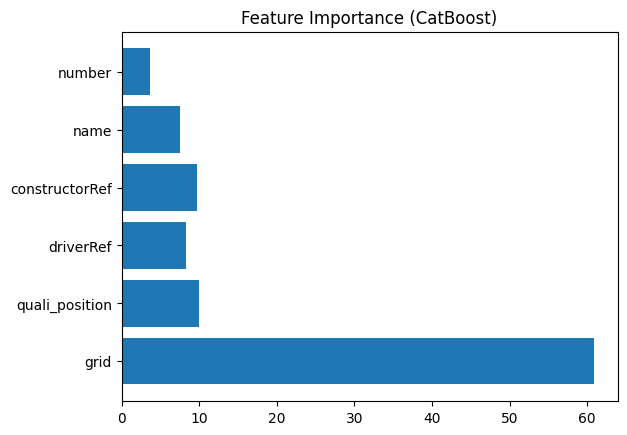

In [154]:
import matplotlib.pyplot as plt

importances = best_cb_model.get_feature_importance()
feature_names = numeric_features + categorical_features

plt.barh(feature_names, importances)
plt.title("Feature Importance (CatBoost)")
plt.show()

Анализ важности признаков показал, что наиболее значимым фактором является стартовая позиция (grid). Более высокая стартовая позиция увеличивает вероятность успешного исхода гонки.

Признак quali_position также оказывает влияние, однако его вклад существенно ниже по сравнению с grid. Категориальные признаки, такие как driverRef и constructorRef, имеют умеренное влияние, что отражает различия между пилотами и командами.

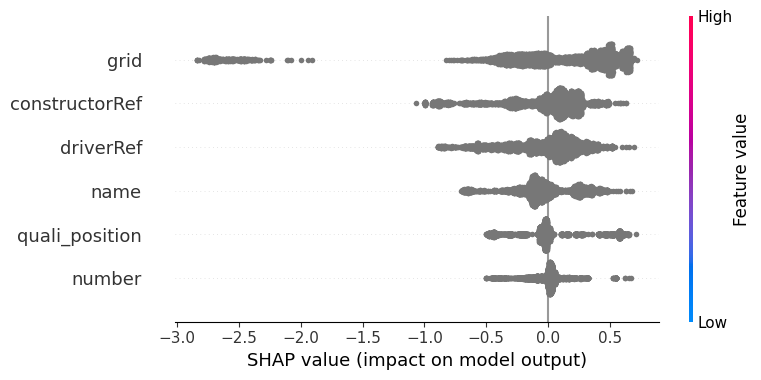

In [155]:
feature_names = numeric_features + categorical_features
X_test_cb_df = pd.DataFrame(X_test_cb, columns=feature_names)

explainer = shap.TreeExplainer(best_cb_model)
shap_values = explainer.shap_values(X_test_cb_df)

shap.summary_plot(shap_values, X_test_cb_df)


SHAP-анализ подтверждает результаты feature importance и показывает, что более высокие значения признака grid чаще увеличивают вероятность положительного класса, тогда как низкие значения уменьшают её. В целом модель использует интерпретируемые и логически обоснованные зависимости.

### Локальная интерпретация

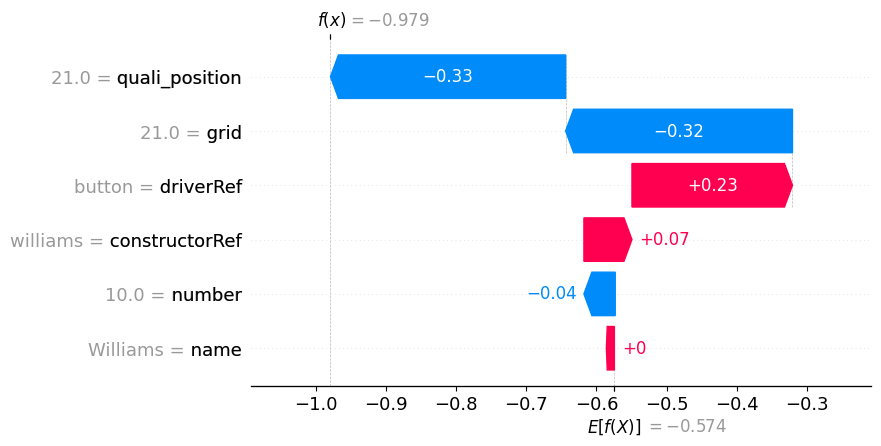

In [156]:
idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_cb_df.iloc[idx, :],
        feature_names=X_test_cb_df.columns.tolist()
    )
)

Для выбранного объекта предсказание модели формируется как сумма вкладов отдельных признаков. Базовое значение модели смещается под влиянием характеристик объекта.

Наибольшее отрицательное влияние оказывают признаки quali_position и grid, что означает, что плохая квалификационная позиция и старт с конца значительно снижают вероятность успешного результата. При этом положительное влияние оказывает признак, связанный с пилотом (driverRef), однако его вклад недостаточен для компенсации негативных факторов, связанных со стартовой позицией и результатами квалификации

### Вывод

На мой взгляд, результаты интерпретации выглядят логично и соответствуют реальности: стартовая позиция и результаты квалификации действительно сильно влияют на исход гонки. Также модель учитывает особенности пилота и команды, что делает её решения понятными и обоснованными